# Метод опорных векторов

 **Теория**:





В основе лежит идея построения разделяющей гиперплоскости, которая максимально удалена от объектов разных классов.
Гиперплоскость дается уравнением $x\cdot w+b=0$. При этом гиперплоскость нужно провести так, чтобы зазор $\dfrac{2}{|w|}$  между опорными векторами был максимальным. Это соответствует минимизации функции $\dfrac{1}{2}|w|^2$ с условием

$y_i(x_iw+b)-1\ge0$





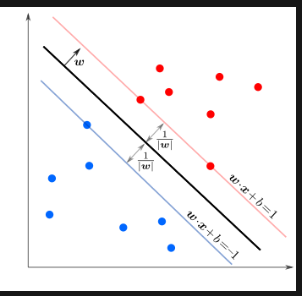

Если точки разных классов взаимно "проникают", то мы уже не можем решить предыдущую задачу оптимизации — не существует параметров удовлетворяющих тем условиям. Тогда можно разрешить точкам нарушать границу на величину $\xi_i \geq 0$, но также желательно, чтобы таких нарушителей было как можно меньше. Этого можно достичь с помощью модификации целевой функции дополнительным слагаемым (регуляризация $L_1$):

$min(\dfrac{1}{2}|w|^2+C\sum\limits_{i}{\xi_i}$)

$\xi_i+y_i(x_iw+b)-1>0$

$\xi_i\ge0$

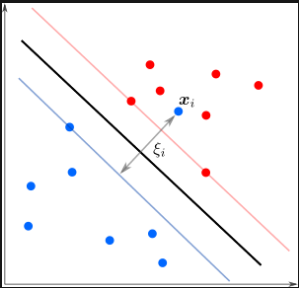

Попробуем реализовать такой код.
Условия:

$\xi_i+y_i(x_iw+b)-1>0$

$\xi_i\ge0$

можно переписать в виде

$\xi_i=\max(0, 1-y^i(w^Tx^i+b)$


Подставляем в функцию потерь

$min(\dfrac{1}{2}|w|^2+C\sum\limits_{i}{\max(0, 1-y^i(w^T*x^i+b)}$)

Рассмотрим $l_i=\max(0, 1-y^i(w^Tx^i+b)$

Если $y^i(w^Tx^i+b)>1$, то $l_i=0$, $\nabla(l_w)=0$, $\nabla(l_b)=0$

Если $y^i(w^Tx^i+b)<1$, то $l_i=1-y^i(w^Tx^i+b)$, $\nabla(l_w)=-y^ix^i$, $\nabla(l_b)=-y^i$


# Реализация

Подключим используемые библиотеки

In [3]:
from sklearn import datasets
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
from typing import List
from sklearn.metrics import accuracy_score

Выгрузим датасет Iris

In [4]:
iris = datasets.load_iris()

Отберем нужные данные, оставим только два класса, т.к метод опорных векторов нужен для бинарной классификации.

In [5]:
X_all = iris.data[:, [2, 3]]  # все строки, два столбца с длиной и шириной лепестка
y_all = iris.target  # метки класса, 0, 1, 2 для классов ирисов

X = X_all[(y_all == 0) | (y_all == 1)]
y = y_all[(y_all == 0) | (y_all == 1)]



Разделяем данные на тренировочные и тестовые

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=1, stratify=y, test_size=0.3
)

Масштабируем признаки

In [7]:
sc = StandardScaler()
sc.fit(
    X_train
)

X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

Реализуем метод опорных векторов

In [8]:
class SVM:

    def __init__(self, eta: float = 0.01, n_iter: int = 50, C=1, random_state: int = 1):
        self.C = C #штраф за неправильное определение
        self.eta = eta #скорость обучения
        self.n_iter = n_iter #количество эпох
        self.random_state = random_state

    def fit(self, X, y) -> object:

        rgen = np.random.RandomState(self.random_state)
        # меняем метки с 0, 1 на -1, 1
        y = y * 2 - 1
        # инициализируем веса
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        # инициализируем смещение
        self.b_ = np.float64(0.0)
        # инициализируем переменную для хранения значения функции потерь в каждой эпохе
        self.losses_: List = []

        # цикл подгонки
        for _ in range(self.n_iter):
            # фактический вход z = X^i * w_i + b
            net_input = self.net_input(X)
            condition = self.activation(X, y) < 1

            grad_w = self.w_.copy()
            grad_b = 0.0

            if np.any(condition):
                grad_w += -self.C * np.dot(X[condition].T, y[condition])
                grad_b += -self.C * np.sum(y[condition])

            grad_w /= X.shape[0]
            grad_b /= X.shape[0]

            self.w_ -= self.eta * grad_w
            self.b_ -= self.eta * grad_b

            loss = 0.5 * np.dot(self.w_, self.w_) + self.C * np.sum(
                np.maximum(0, 1 - y * net_input)
            )
            self.losses_.append(loss)
            new_margin = self.activation(X, y)
        return self

    def net_input(self, X):# значения которые мы вычисляем:уравнение гиперплоскости
        return np.dot(X, self.w_) + self.b_

    def activation(self, X, y):# домножения нашей гиперплоскости на y
        return y * self.net_input(X)

    def predict(self, X):
        return (np.sign(self.net_input(X))+1)//2

Обучим модель

In [9]:
svm = SVM(eta=0.3, n_iter=100, C=1.0, random_state=1)
svm.fit(X_train_std, y_train)

Проверим точность метода с помощью функции accuracy_score из библиотеки scikit-learn.

In [10]:
y_pred = svm.predict(X_test_std)
accuracy = accuracy_score(y_test, y_pred)
print(f'Точность метода составляет {accuracy}')

Точность метода составляет 1.0


Построим график

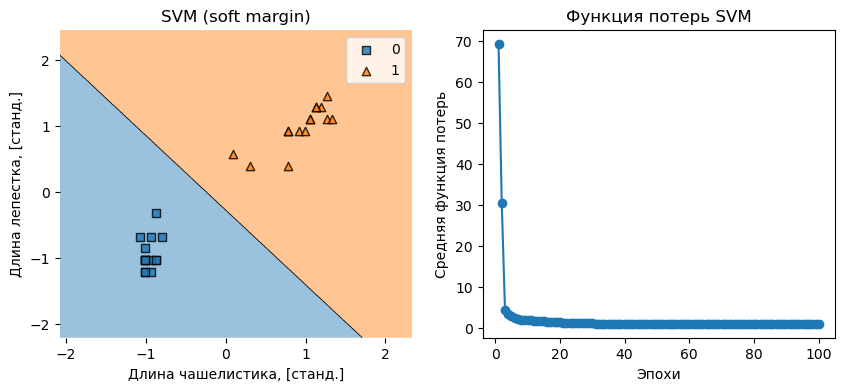

In [11]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

plot_decision_regions(X_test_std, y_test, clf=svm, ax=ax[0])
ax[0].set_xlabel("Длина чашелистика, [станд.]")
ax[0].set_ylabel("Длина лепестка, [станд.]")
ax[0].set_title("SVM (soft margin)")
ax[0].legend(loc="upper right")

ax[1].plot(range(1, len(svm.losses_) + 1), svm.losses_, marker="o")
ax[1].set_xlabel("Эпохи")
ax[1].set_ylabel("Средняя функция потерь")
ax[1].set_title("Функция потерь SVM")

plt.show()

# Используем данные, в которых метки одного класса залезают в область меток другого класса.
Для этого используем датасет make_blobs.

In [12]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=200, centers=2, cluster_std=2.5, random_state=42)

Разделим выборку.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=1, stratify=y, test_size=0.3
)

Масштабируем признаки.

In [14]:
sc = StandardScaler()
sc.fit(
    X_train
)

X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

Обучим модель.

In [15]:
svm = SVM(eta=0.3, n_iter=100, C=1.0, random_state=1)
svm.fit(X_train_std, y_train)

Оцениваем точность.

In [16]:
y_pred = svm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Точность метода составляет {accuracy}')

Точность метода составляет 0.9166666666666666


Строим график.

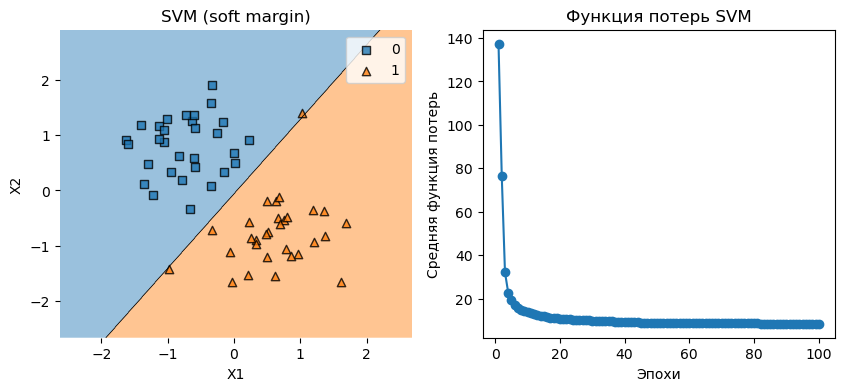

In [17]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

plot_decision_regions(X_test_std, y_test, clf=svm, ax=ax[0])
ax[0].set_xlabel("X1")
ax[0].set_ylabel("X2")
ax[0].set_title("SVM (soft margin)")
ax[0].legend(loc="upper right")

ax[1].plot(range(1, len(svm.losses_) + 1), svm.losses_, marker="o")
ax[1].set_xlabel("Эпохи")
ax[1].set_ylabel("Средняя функция потерь")
ax[1].set_title("Функция потерь SVM")

plt.show()

# Попробуем добавить функцию ядра

Что делать, если данные линейно-неразделимы как на рисунке? Нужно добавить функцию ядра.

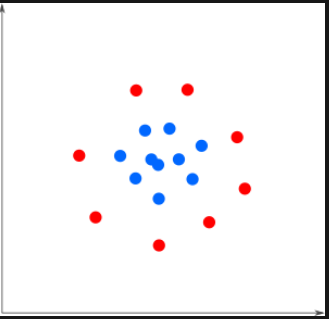

Чтобы перейти к функции ядра нужно рассмотреть двойственную (дуальную) задачу Лагранжа.


Прямую задачу мы уже знаем:

$min(\dfrac{1}{2}|w|^2+C\sum\limits_{i}{\xi_i}$)

$\xi_i+y_i(x_iw+b)-1>0$

$\xi_i\ge0$


Для поиска двойной задачи введем множители Лагранжа:

$\alpha_i\ge 0$ для каждого неравенства $y_i(x_iw+b)>1-\xi_i$

$β\ge0$ для каждого $\xi_i \ge 0$

Тогда функцию Лагранжа можно переписать в виде:

$L = \dfrac{1}{2}||w||^2+C\sum\limits_{i=1}^{n}\xi_i -\sum\limits_{i=1}^{n}\alpha_i[y_i(wx_i+b)-1+\xi_i] - \sum\limits_{i=1}^{n}β_i\xi_i$

Рассмотрим условия Каруша-Куна-Такера - они позволяют проверить, является ли найденная точка решением прямой задачи, не перебирая все возможные варианты. Если условия выполнены — решение оптимально.

$\frac{\partial L}{\partial w}$ = w - $\sum\limits_{i=1}^{n}\alpha_iy_ix_i =0$
 $→ w = \sum\limits_{i=1}^{n}\alpha_iy_ix_i$

$\frac{\partial L}{\partial b}$ = -$\sum\limits_{i=1}^{n}\alpha_iy_i → \sum\limits_{i=1}^{n}\alpha_iy_i = 0$

$\frac{\partial L}{\partial \xi_i}$ = C - $\alpha_i -\beta_i = 0 \rightarrow \alpha_i = C - \beta_i$

Т.к. $\beta_i \ge 0 ;  \alpha_i \ge 0 \rightarrow 0 \le \alpha_i\le C$

Ограничения для двойной задачи:

$0 \le \alpha_i\le C,  \sum\limits_{i=1}^{n}\alpha_iy_i = 0$

Подставляем в функцию Лагранжа, после преобразований, получим:

$L = \sum\limits_{i=1}^n\alpha_i - \dfrac{1}{2}\sum\limits_{i}\sum\limits_{j}\alpha_i\alpha_jy_iy_j(x_i, x_j)$

$K(x_i, x_j) = \phi(x_i)\cdot\phi(x_j)$ - функция ядра

$0≤α_i≤C,\sum\limits_{i=1}^{n}\alpha_iy_i = 0$


Из-за того, что мы перешли к двойной задаче, чтобы минимизировать функцию по $\xi_i, w$, нам нужно максимизировать L по $\alpha$.


$\max (\sum\limits_{i=1}^n\alpha_i - \dfrac{1}{2}\sum\limits_{i}\sum\limits_{j}\alpha_i\alpha_jy_iy_j(x_i, x_j))$

После чего нужно найти b:

$b = y_i -wx_i=y_i-\sum\limits_{j}^n\alpha_jy_jK(x_j, x_i)$

На практике берут усреднение по всем индексам:

$b =\dfrac{1}{|S|}\sum\limits_{i \in S}(y_i-\sum\limits_{j}^n\alpha_jy_jK(x_j, x_i))$

А классификатор будет иметь такой вид:

$f(x) = \sum\limits_{i}^n{\alpha_iy_iK(x_i,x_j)+b}$

$class(x)=sign(f(x))$

# Алгоритм SMO

Как в работе https://habr.com/ru/articles/544282/ несколько упрощений.

1. Вместо подбора обоих индексов для дуальных переменных, автор задает $\alpha_L$ рандомно, а $\alpha_M$ подбирается итерационно.
2. Отказывается от проверки ККТ и выполняет наперёд заданное число итераций.
3. Пользуется векторным уравнением прямой.

Информацию из обучающей выборки можно представить в виде матрицы К.

$K = \begin{pmatrix}
y_1y_1K(x_1;x_1) & y_1y_2K(x_1;x_2) & ... & y_1y_NK(x_1;x_N) \\
y_2y_1K(x_2;x_1) & y_2y_2K(x_2;x_2) & ... & y_2y_NK(x_2;x_N) \\
... & ... & ... & ... \\
y_Ny_1K(x_N;x_1) & y_Ny_2K(x_N;x_2) & ... & y_Ny_1N(x_N;x_N)
\end{pmatrix}$

$\alpha$ будет представлять собой вектор-столбец, тогда перепишем Лагранжиан в таком виде:

$\max (\sum\limits_{i=1}^n\alpha_i - \dfrac{1}{2}\alpha^TK\alpha)$

Выделим какие-то $\alpha_M, \alpha_L$ среди всех  $\alpha_i, \alpha_j$

Перепишем задачу, объединив все, что не содержит $\alpha_M$ или $\alpha_L$.

L = $\alpha_M + \alpha_L - \sum\limits_{j}\alpha_M\alpha_jK_{M,j} - \sum\limits_{i}\alpha_L\alpha_iK_{L,i} + const + \dfrac{1}{2}\alpha_M^2K_{M,M}+\alpha_M\alpha_LK_{M,L}+\dfrac{1}{2}\alpha_L^2K_{L,L} = \alpha_M(1 - \sum\limits_{j}\alpha_jK_{M,j})+ \alpha_L(1-\sum\limits_{i}\alpha_iK_{L,i})+\dfrac{1}{2}(\alpha_M^2M_{M,M} + 2\alpha_M\alpha_LK_{M,L}+\alpha_L^2K_{L,L}) + const = k_0^Tv_0+\dfrac{1}{2}v_0^TQv_0+const$

Где $const$ - слагаемые, не зависящие от $\alpha_L$ или $\alpha_M$. А также были использованы переназначения:

$
v_0 = (\alpha_M, \alpha_L)^T,$


$k_0 = (1 - \alpha^T K_M, \; 1 - \alpha^T K_L)^T,$

$Q =
\begin{pmatrix}
K_{M,M} & K_{M,L} \\
K_{L,M} & K_{L,L}
\end{pmatrix},$


$u = (-y_L, \; y_M)^T.
$

У нас есть условия:

$y_L\alpha_l+y_M\alpha_M = const$

$0\le\alpha_L\le C$, $0\le\alpha_M\le C$

Мы хотим выполнить максимизацию так, чтобы $y_L\alpha_l+y_M\alpha_M$ оставалось постоянным. Для этого новые значения должны лежать на одной прямой.

 $(\alpha_M^{new}, \alpha_L^{new})^T = v(t) = v_0 + tu$.

 Убедимся в том, что для любого t выполняет условие, для этого просто подставим в наше выражение $v_0$ и $u$.

 $y_M \alpha_M^{\text{new}} + y_L \alpha_L^{\text{new}} = y_M \alpha_M + y_L \alpha_L + t(-y_M y_L + y_L y_M) = y_M \alpha_M + y_L \alpha_L$

Тогда мы должны максимизировать

$L(t) = (k_0 + Q v_0)^T v(t) - \frac{1}{2} v^T(t) Q v(t) + \text{const}$

Берем производную:

$\frac{d{L}(t)}{dt} = (k_0 + Qv_0)^T \frac{dv}{dt} - \frac{1}{2} \left( \frac{d(v^T Q v)}{dv} \right)^T \frac{dv}{dt} = k_0^T u + v_0^T Q^T u - v^T Q^T u = k_0^T u - t\,u^T Q u.$

Приравниваем ее к нулю, получаем:

$t_* = \dfrac{k_0^Tu}{u^TQu}$

Представим наши условия в виде такого графика (см. картинку). Важно не выйти за него, поэтому когда выйдем за пределы квадрата нужно вернуться на его границу.

$\left( \alpha_M^{\text{new}}, \alpha_L^{\text{new}} \right) = v_0 + t_*^{\text{restr}} u.$

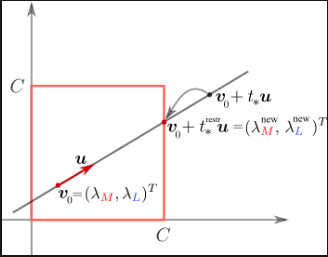

На этом итерации завершаются и выбираются новые индексы.

Для наглядности автор приводит схему обучения:

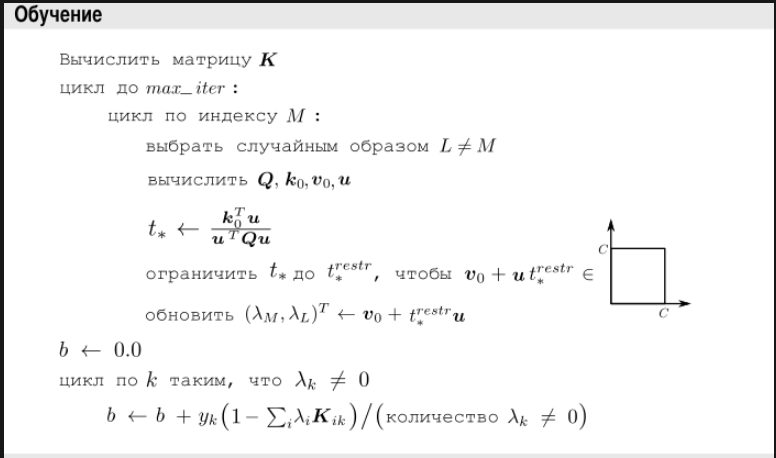

Обучим вторую модель на линейно-неразделимом наборе данных. Создадим такой датасет с помощью make_moons. Он генерирует два признака и метку класса.

In [18]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=200, noise=0.05, random_state=42)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=1, stratify=y, test_size=0.3
)

Метод опорных векторов с функциями ядер:

In [20]:
class SVM1:
  def __init__(self, kernel='linear', C=10000.0, max_iter=100000, degree=3, gamma=1):
    self.kernel = {'poly'  : lambda x,y: np.dot(x, y.T)**degree,
         'rbf': lambda x,y: np.exp(-gamma*np.sum((y-x[:,np.newaxis])**2,axis=-1)),
         'linear': lambda x,y: np.dot(x, y.T)}[kernel]
    self.C = C
    self.max_iter = max_iter

  def restrict_to_square(self, t, v0, u):
    t = (np.clip(v0 + t*u, 0, self.C) - v0)[1]/u[1]
    return (np.clip(v0 + t*u, 0, self.C) - v0)[0]/u[0]

  def fit(self, X, y):
    self.X = X.copy()
    self.y = y * 2 - 1
    self.alphas = np.zeros_like(self.y, dtype=float)
    self.K = self.kernel(self.X, self.X) * np.outer(self.y, self.y)
    self.losses_: List = []

    for _ in range(self.max_iter):
      for idxM in range(len(self.alphas)):
        idxL = np.random.randint(0, len(self.alphas))
        Q = self.K[[[idxM, idxM], [idxL, idxL]], [[idxM, idxL], [idxM, idxL]]]
        v0 = self.alphas[[idxM, idxL]]
        k0 = 1 - np.sum(self.alphas * self.K[[idxM, idxL]], axis=1)
        u = np.array([-self.y[idxL], self.y[idxM]])
        t_max = np.dot(k0, u) / (np.dot(np.dot(Q, u), u) + 1E-15)
        self.alphas[[idxM, idxL]] = v0 + u * self.restrict_to_square(t_max, v0, u)

      loss = np.sum(self.alphas) - 0.5 * np.dot(self.alphas, np.dot(self.K, self.alphas))
      self.losses_.append(loss)
    # найти индексы опорных векторов
    idx, = np.nonzero(self.alphas > 1E-15)
    self.b = np.mean((1.0-np.sum(self.K[idx]*self.alphas, axis=1))*self.y[idx])


  def decision_function(self, X):
    return np.sum(self.kernel(X, self.X) * self.y * self.alphas, axis=1) + self.b

  def predict(self, X):
    return (np.sign(self.decision_function(X)) + 1) // 2

Обучение модели

In [21]:
svm1 = SVM1(kernel = 'rbf', C = 500, max_iter = 1000, degree = 2, gamma = 0.5)
svm1.fit(X_train, y_train)

Проверка accuracy_score

In [22]:
y_pred = svm1.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Точность метода составляет {accuracy}')

Точность метода составляет 1.0


Построение графика

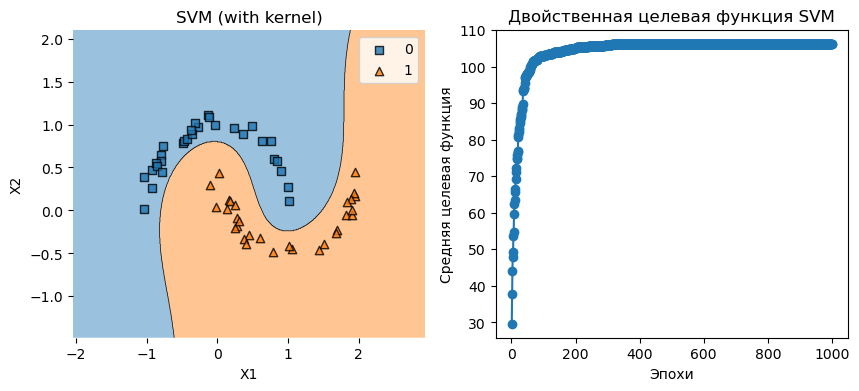

In [23]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

plot_decision_regions(X_test, y_test, clf=svm1, ax=ax[0])
ax[0].set_xlabel("X1")
ax[0].set_ylabel("X2")
ax[0].set_title("SVM (with kernel)")
ax[0].legend(loc="upper right")

ax[1].plot(range(1, len(svm1.losses_) + 1), svm1.losses_, marker="o")
ax[1].set_xlabel("Эпохи")
ax[1].set_ylabel("Средняя целевая функция")
ax[1].set_title("Двойственная целевая функция SVM")

plt.show()

Как мы видим, двойственная целевая функция растет и выходит на плато, что соответствует максимизации этой двойной функции, значит результат верный.

Сравним результат с тем, что получается с помощью модуля svm из библиотеки scikit-learn.

In [24]:
from sklearn.svm import SVC
svm = SVC(kernel='rbf', C=1.0, random_state=1)
svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [25]:
y_pred = svm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Точность метода составляет {accuracy}')

Точность метода составляет 1.0


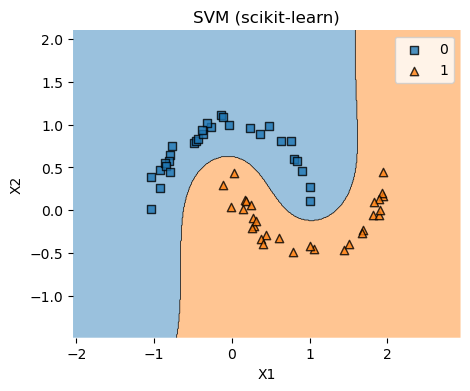

In [26]:
fig, ax = plt.subplots(figsize=(5, 4))

plot_decision_regions(X_test, y_test, clf=svm)
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_title("SVM (scikit-learn)")
ax.legend(loc="upper right")

plt.show()

Результаты похожи, что свидетельствует о правильности обучения модели.